Author : Jesse Gunn Cheu

In [238]:
# Import Packages
# Basics
from __future__ import annotations
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

# Stats & Viz
from itertools import combinations # Suggested by ChatGPT
from scipy.stats import zscore
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import pairwise_distances
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay, f1_score, log_loss
from sklearn import tree
from sklearn.metrics import ConfusionMatrixDisplay

# Train/Test Split & CV
from sklearn.model_selection import train_test_split, KFold
from sklearn.utils import shuffle
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.model_selection import GridSearchCV

# Classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# MINE
import importlib

import kmer_polished
importlib.reload(kmer_polished)

<module 'kmer_polished' from 'w:\\Projects\\ImmunoglobulinML\\kmer_polished.py'>

In [54]:
# Loading data or making dataframes from gff files if csv files not found
try :
    raw_df = pd.read_csv('igl_raw_2_ 3_ 6_kmers.csv')
except FileNotFoundError:
    print("File not found for raw_df, making raw_df from gff")
    raw_df = kmer_polished.beautify_gff("HLepoLabi.1.2.h1.cur.20251110.2bit", "Data/epolab_hap1_digger_igl_annotations_raw.gff", "raw")

try :
    cur_df = pd.read_csv('igl_cur_2_ 3_ 6_kmers.csv')
except FileNotFoundError:
    print("File not found for cur_df, making cur_df from gff")
    cur_df = kmer_polished.beautify_gff("HLepoLabi.1.2.h1.cur.20251110.2bit", "Data/epolab_hap1_digger_annotations_igl_polished.gff", "cur")

full_df = pd.concat([raw_df, cur_df], ignore_index=True)

In [149]:
cur_df.head()

,contig,source,feature,start,end,length,seq,2mer_AA,2mer_AC,2mer_AG,...,6mer_TTTTCG,6mer_TTTTCT,6mer_TTTTGA,6mer_TTTTGC,6mer_TTTTGG,6mer_TTTTGT,6mer_TTTTTA,6mer_TTTTTC,6mer_TTTTTG,6mer_TTTTTT
0,Chr_5,cur,IGLV (Pseudo),17026040,17026356,317,TTTGTGAATTATTCTGCTGAAGTCTGGGAGCTCTGCTCAATTTTTT...,0.069401,0.018927,0.059937,...,0.0,0.0,0.0,0.0,0.0,0.0,0.003155,0.0,0.0,0.006309
1,Chr_5,cur,RSS23 (IGLV),17026002,17026039,38,CACAGTGCTCCGGCCCAGTGGAGAGTGAGGCATAAACC,0.052632,0.052632,0.131579,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
2,Chr_5,cur,IGLV (Pseudo),17024298,17024596,299,ATACTAGACTCACAACCCTCTGTCTCACTGTATTGGTCATTTGGTT...,0.060201,0.050167,0.053512,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
3,Chr_5,cur,RSS23 (IGLV),17024260,17024297,38,CACAGCTTGTGACCAACATTAGCTCACTGGGGATATTT,0.026316,0.105263,0.052632,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
4,Chr_5,cur,IGLV (ORF),17017423,17017722,300,GAGTTTGTGCTGACGCAGCCCCACTCCGTGTCGGGGTCTCCGGGGC...,0.046667,0.063333,0.066667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000


In [139]:
# Using str.extract with regex
full_df[['gene_type', 'gene_function']] = full_df['feature'].str.extract(r'(\S+)\s+\(([^)]+)\)')

C:\Users\jesse\AppData\Local\Temp\ipykernel_16996\2432284807.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_df[['gene_type', 'gene_function']] = full_df['feature'].str.extract(r'(\S+)\s+\(([^)]+)\)')


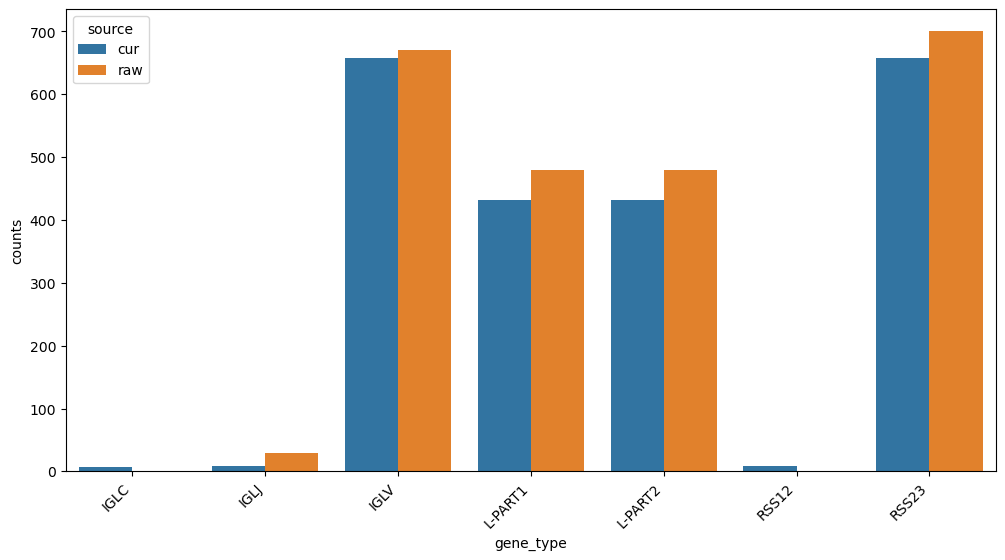

In [140]:
# Take a look at the distribution of features in the raw and polished datasets
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=full_df.groupby(['source', 'gene_type']).size().reset_index(name='counts'),
    x='gene_type',
    y='counts',
    hue='source'
)
# Rotate x-axis labels for better readability and move to the right
plt.xticks(rotation=45, ha='right')

#save graph
plt.savefig('viz/feature_counts_by_source.png', bbox_inches='tight')
plt.show()

In [158]:
# Get differences in feature counts between raw and polished datasets
feature_counts = full_df.groupby(['source', 'gene_type']).size().reset_index(name='counts').pivot(index='gene_type', columns='source', values='counts').fillna(0)
feature_counts['difference'] = feature_counts['cur'] - feature_counts['raw']
feature_counts = feature_counts.sort_values(by='difference', ascending=True)
print(feature_counts[['raw', 'cur', 'difference']])

source       raw    cur  difference
gene_type                          
L-PART1    479.0  432.0       -47.0
L-PART2    479.0  432.0       -47.0
RSS23      700.0  658.0       -42.0
IGLJ        29.0    9.0       -20.0
IGLV       671.0  658.0       -13.0
IGLC         0.0    7.0         7.0
RSS12        0.0    9.0         9.0


# Preprocessing
Select for one feature type
Remove kmer columns with one value
Apply Z-score
Downcast

In [159]:
selected_feature = "RSS23"
print(f"Select for {selected_feature} features for testing purposes, and apply column reduction and normalization to k-mer columns.")
filter_full = full_df[(full_df['gene_type'] == selected_feature)] # Select by gene_type (for testing purposes)  & (full_df['new_func'] == 'Functional')

for col in filter_full.columns :
    # These steps will alter kmer columns to reduce size overall
    if "mer" in col :
        if filter_full[col].nunique() == 1:
            # Remove col if it is only 1 variable
            filter_full.drop(col, axis = 1, inplace=True);
            print(f"Dropped column {col}")
        else :
            # Downcast to float to save memory
            filter_full[col] = (filter_full[col] - filter_full[col].mean()) / filter_full[col].std() # Z-score normalization
            filter_full[col] = pd.to_numeric(filter_full[col], downcast="float");

# Add categorical columns
filter_full['source'] = filter_full['source'].astype('category') # Convert Target to categorical
filter_full["seq_ID"] = [f"seq_{i}" for i in range(len(filter_full))] # Add sequence ID
filter_full = filter_full.set_index('seq_ID') # Set sequence ID as index

print(filter_full.info())
filter_full.head()

Select for RSS23 features for testing purposes, and apply column reduction and normalization to k-mer columns.
Dropped column 6mer_AAAAGA
Dropped column 6mer_AAAAGG
Dropped column 6mer_AAAATT
Dropped column 6mer_AAACAG
Dropped column 6mer_AAACAT
Dropped column 6mer_AAACGA
Dropped column 6mer_AAACGC
Dropped column 6mer_AAACGG
Dropped column 6mer_AAACGT
Dropped column 6mer_AAACTA
Dropped column 6mer_AAACTG
Dropped column 6mer_AAACTT
Dropped column 6mer_AAAGAC
Dropped column 6mer_AAAGAG
Dropped column 6mer_AAAGCA
Dropped column 6mer_AAAGCT
Dropped column 6mer_AAAGGA
Dropped column 6mer_AAAGGG
Dropped column 6mer_AAAGGT
Dropped column 6mer_AAATAC
Dropped column 6mer_AAATAT
Dropped column 6mer_AAATCA
Dropped column 6mer_AAATCG
Dropped column 6mer_AAATCT
Dropped column 6mer_AAATGT
Dropped column 6mer_AAATTA
Dropped column 6mer_AAATTC
Dropped column 6mer_AAATTT
Dropped column 6mer_AACAAC
Dropped column 6mer_AACAAG
Dropped column 6mer_AACACC
Dropped column 6mer_AACACT
Dropped column 6mer_AACAG

C:\Users\jesse\AppData\Local\Temp\ipykernel_16996\4200828307.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  filter_full["seq_ID"] = [f"seq_{i}" for i in range(len(filter_full))] # Add sequence ID


,contig,source,feature,start,end,length,seq,2mer_AA,2mer_AC,2mer_AG,...,6mer_TTTGAT,6mer_TTTGCA,6mer_TTTGCT,6mer_TTTGGA,6mer_TTTTAA,6mer_TTTTCT,6mer_TTTTTC,6mer_TTTTTT,gene_type,gene_function
seq_ID,,,,,,,,,,,,,,,,,,,,,
seq_0,Chr_5,raw,RSS23 (IGHJ),1294653,1294659,7,TGCAAAG,3.997619,-2.803791,0.997464,...,-0.038391,-0.15529,-0.027136,-0.054328,-0.027136,-0.094386,-0.094386,-0.094386,RSS23,IGHJ
seq_1,Chr_5,raw,RSS23 (IGHJ),1861070,1861076,7,CCCAGCG,-2.192994,-2.803791,0.997464,...,-0.038391,-0.15529,-0.027136,-0.054328,-0.027136,-0.094386,-0.094386,-0.094386,RSS23,IGHJ
seq_2,Chr_5,raw,RSS23 (IGHJ),2888165,2888191,27,CCCTCTGCCCAACACATACCCAAATCC,0.214466,0.215139,-2.462360,...,-0.038391,-0.15529,-0.027136,-0.054328,-0.027136,-0.094386,-0.094386,-0.094386,RSS23,IGHJ
seq_3,Chr_5,raw,RSS23 (IGHJ),5027241,5027247,7,TACTGTC,-2.192994,1.077691,-2.462360,...,-0.038391,-0.15529,-0.027136,-0.054328,-0.027136,-0.094386,-0.094386,-0.094386,RSS23,IGHJ
seq_4,Chr_5,raw,RSS23 (IGHV),6818430,6818467,38,CTCAGGGACCTATTTGCTCAGAAGTCACTCTTGAGTAG,-1.622806,-1.373771,0.724320,...,-0.038391,-0.15529,36.823914,-0.054328,-0.027136,-0.094386,-0.094386,-0.094386,RSS23,IGHV


# Remove similar sequences

In [363]:
duplicate_seqs = filter_full.groupby(['start', 'end', 'seq', 'source']).size()
duplicate_seqs.sort_values(ascending=False)

start      end        seq                                      source
1294653    1294659    TGCAAAG                                  raw       1
16015297   16015335   CACGGTGACACACATAGATGAGTAAGTGAGACAAAAACC  raw       1
16031036   16031074   TCCAGCGATGACTGACATTTGCAGAAGCAGAGAGGGACC  raw       1
                                                               cur       1
16028401   16028438   CACAGTGACACAGGCAGAGGAGAAGTGAGACAAAAACC   raw       1
                                                                        ..
14984076   14984114   CACAGTAACACGTGCGGATGGGGAAGTGGGACAAAAACC  cur       1
14982943   14982980   CCCGAGGATCTCCTGTTTCTGGGGACATGTGATAAATC   raw       1
                                                               cur       1
14977949   14977987   CACATTGCTCCGGGCCCGTGGGGAAGTGAGACAAGAACC  raw       1
125679201  125679207  CACGGTG                                  raw       1
Length: 1358, dtype: int64

In [1]:
# Reformat to only numeric columns for pdist
num_df = filter_full.select_dtypes(include=[np.number])
num_df = num_df.drop(columns=['length']) # Drop non-informative columns

NameError: name 'filter_full' is not defined

In [333]:
num_df_rounded = num_df.round(10) # Round to 4 decimal places to reduce memory usage

In [339]:
# Create distance matrix
pdist_matrix = pairwise_distances(num_df_rounded, metric='euclidean')
pdist_matrix[pdist_matrix < 1e-10] = 0.0 # Set very small distances to zero to avoid floating point issues
distmat = pd.DataFrame(pdist_matrix, index=num_df_rounded.index, columns=num_df_rounded.index) # Automatic help from CoPilot
print(distmat.shape)
distmat.head(3)

(1358, 1358)


seq_ID,seq_0,seq_1,seq_2,seq_3,seq_4,seq_5,seq_6,seq_7,seq_8,seq_9,...,seq_1348,seq_1349,seq_1350,seq_1351,seq_1352,seq_1353,seq_1354,seq_1355,seq_1356,seq_1357
seq_ID,,,,,,,,,,,,,,,,,,,,,
seq_0,0.000000,67.834351,152.191895,69.261856,157.058578,77.449959,175.101395,117.636398,126.240410,126.826126,...,66.566109,50.233326,93.121094,56.931789,130.695404,134.928833,50.233326,74.529449,53.045147,82.709419
seq_1,67.834351,0.000000,152.718140,71.249496,157.871414,79.069374,175.762131,118.405556,127.205917,127.654358,...,69.295349,53.345642,95.137825,59.965023,131.549408,135.168152,53.345642,75.903679,55.794594,84.880867
seq_2,152.191895,152.718140,0.000000,153.183060,208.530014,157.315033,222.216736,180.629181,186.485001,187.093735,...,153.091125,146.501984,166.246841,149.031265,189.617676,189.597244,146.501984,156.405289,147.537323,159.236160


In [340]:
# Reformat the output so we can see all the sequence pairs and distances
tmp = distmat.copy()
tmp.index.name = "row_id"
tmp.columns.name = "col_id"

pairs_df = (
    tmp.stack()
       .reset_index()
       .rename(columns={"row_id": "seq_first", "col_id": "seq_second", 0: "distance"})
)

pairs_df = pairs_df[pairs_df["seq_first"] < pairs_df["seq_second"]]
print(pairs_df.shape)
pairs_df.head(3)

(921403, 3)


,seq_first,seq_second,distance
1,seq_0,seq_1,67.834351
2,seq_0,seq_2,152.191895
3,seq_0,seq_3,69.261856


In [337]:
print(filter_full.loc["seq_730"]["seq"] == filter_full.loc["seq_825"]["seq"])
for mer in filter_full.columns :
    if "mer" in mer :
        if filter_full.loc["seq_730"][mer] != filter_full.loc["seq_825"][mer] :
            print(f"{mer}: {filter_full.loc['seq_730'][mer]} vs {filter_full.loc['seq_825'][mer]}")

True


<Axes: xlabel='distance', ylabel='Count'>

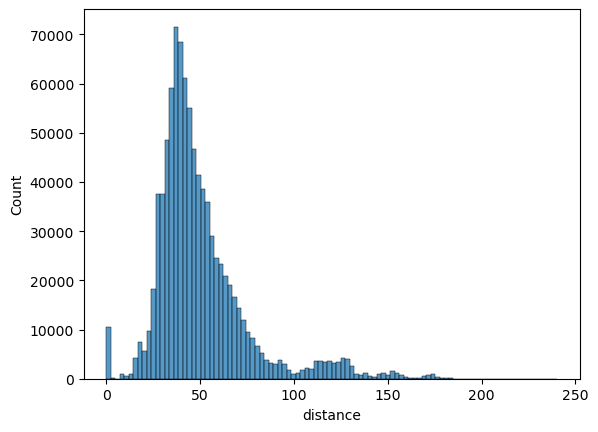

In [341]:
sns.histplot(pairs_df["distance"], bins=100)

I am looking at this plot in order to see if there is a cutoff point other than 0 that might show if two sequences are similar enough to call the same. For now I am going to use a distance of 0.1 because anything higher removed too many sequences to identify the same sequences.

In [342]:
# Identify duplicates based on a distance threshold

pairs_dup = pairs_df[pairs_df["distance"] == 0]
seq_ids = set(pairs_dup["seq_first"]).union(set(pairs_dup["seq_second"]))
seq_ids_list = list(seq_ids)
seq_ids_list[:5] # This is what we are going to use to remove duplicates

['seq_111', 'seq_208', 'seq_92', 'seq_1322', 'seq_723']

In [343]:
# Filter out duplicates from Digger sequences only

before_count = filter_full.shape[0]
filter_full_pol = filter_full[filter_full["source"] == "cur"]
filter_full_dig = filter_full[filter_full["source"] == "raw"]
filter_full_dig = filter_full_dig[~filter_full_dig.index.isin(seq_ids_list)]
filter_final = pd.concat([filter_full_pol, filter_full_dig])
after_count = filter_final.shape[0]
print(f"Before count: {before_count}, After count: {after_count}")
print(f"curated count: {filter_full_pol.shape[0]}, digger count: {filter_full_dig.shape[0]}")

Before count: 1358, After count: 858
curated count: 658, digger count: 200


Here we were able to succesfully create the dataframe we will need for our analysis and classifier. Hopefully we will not be seeing a great deal of overlap between the digger and curated annotations because we did this filtering.

# EDA
For my EDA I am going to first check distribution to see if it is more even now that I have removed the duplicates. I am then interesting in seeing the PCA plots and if there is a semi-clear distinction between the classes. I will also then see if any specific features are highly different between the classes in their counts.

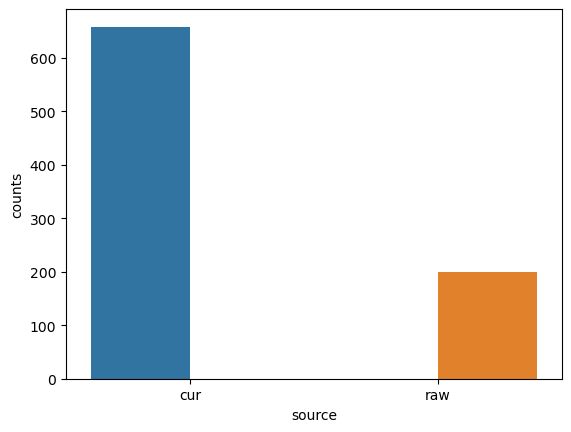

In [344]:
# Visualize final counts to see ditribution between classes

filter_viz = filter_final.groupby('source').size().reset_index(name = 'counts');
sns.barplot(data=filter_viz, x='source', y='counts', hue ='source');

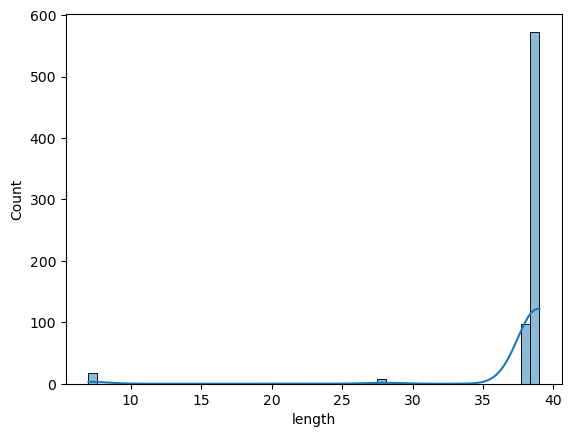

In [181]:
# Visualize length distribution

sns.histplot(filter_final['length'], bins=50, kde=True);

In [182]:
# Prepare data for PCA
pca_df = pd.concat([filter_final.loc[:, filter_final.columns.str.contains("mer")], filter_final['length']], axis=1)
#zscore_df = pca_df.apply(zscore)

In [183]:
# Perform PCA

pca = PCA(pca_df.shape[0])
pca_df = pd.DataFrame(pca.fit_transform(pca_df))

# Generated by ChatGPT
summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(pca.n_components_)],
    "Explained Variance": pca.explained_variance_,
    "Explained Variance Ratio": pca.explained_variance_ratio_,
})

print(summary.head(5))

    PC  Explained Variance  Explained Variance Ratio
0  PC1           44.165533                  0.024161
1  PC2           41.282761                  0.022584
2  PC3           39.698048                  0.021717
3  PC4           34.956602                  0.019123
4  PC5           34.323920                  0.018777


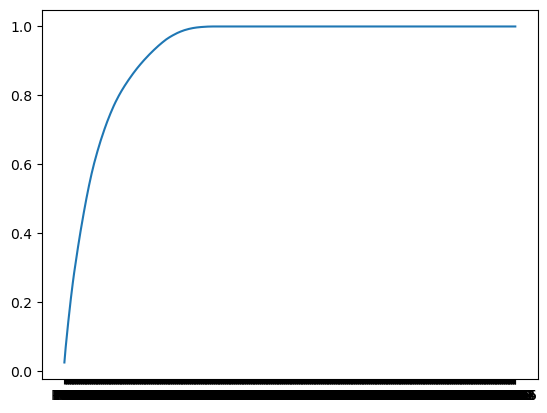

In [184]:
# Plot cumulative explained variance

# Help from ChatGPT
cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.plot([f"PC{i}" for i in range(1, pca_df.shape[0] + 1)], cum_var)

It does not seem like we can reliably compress our data into a small number of dimensions.

In [185]:
pca_plot_df = pd.concat([pca_df.iloc[:, 0:3], filter_final['source'].reset_index(drop=True)], axis=1)
pca_plot_df.columns = ['PC1', 'PC2', 'PC3', 'source']

Text(0.5, 0, 'PC3')

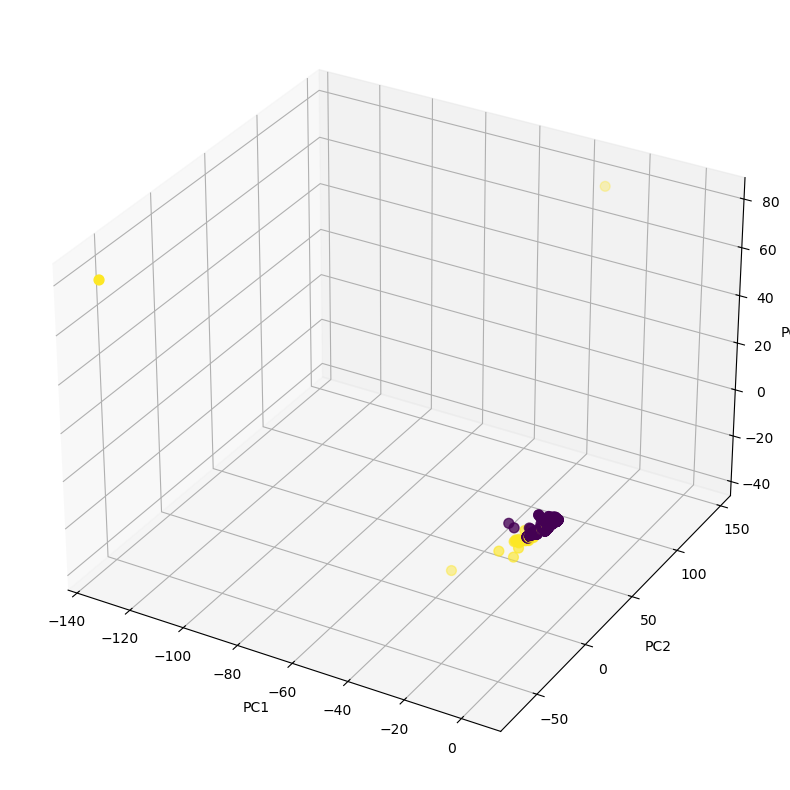

In [346]:
# ANSWER

fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(pca_plot_df.iloc[:,0], pca_plot_df.iloc[:,1], pca_plot_df.iloc[:,2], c=pca_plot_df['source'].cat.codes, cmap='viridis', s=50)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")


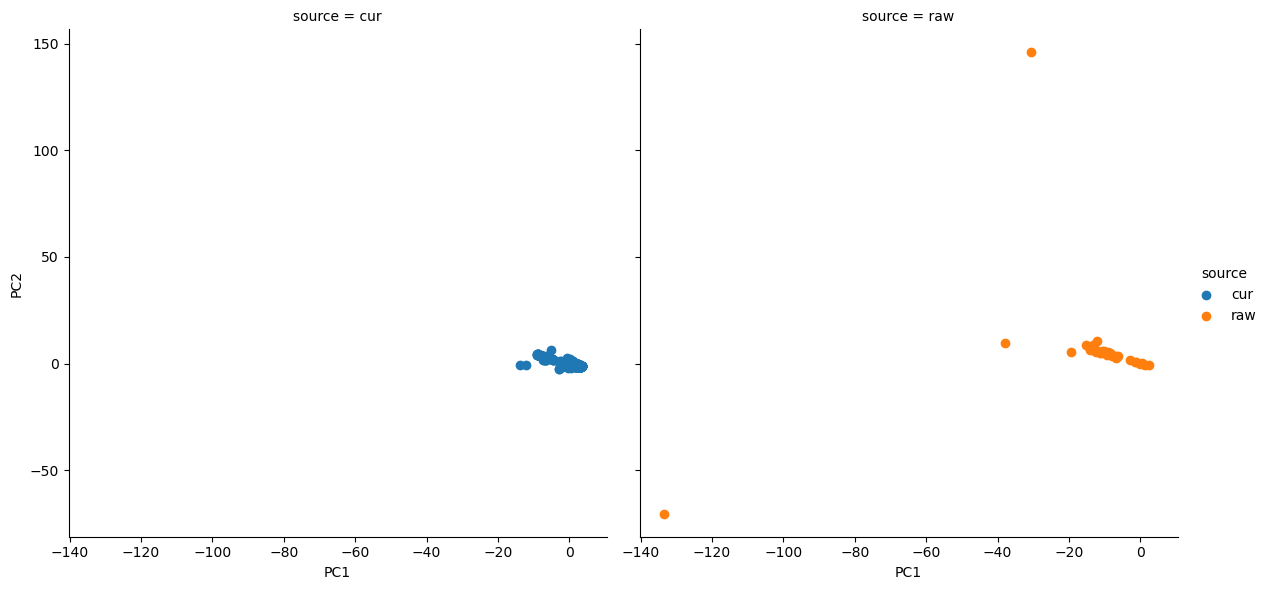

In [345]:
# This is to see if there was overlap that can be difficult to see if there was a lot of overlap
g = sns.FacetGrid(pca_plot_df, col = 'source', hue="source", height=6)
g.map(plt.scatter, "PC1", "PC2").add_legend()

<Axes: xlabel='PC1', ylabel='PC2'>

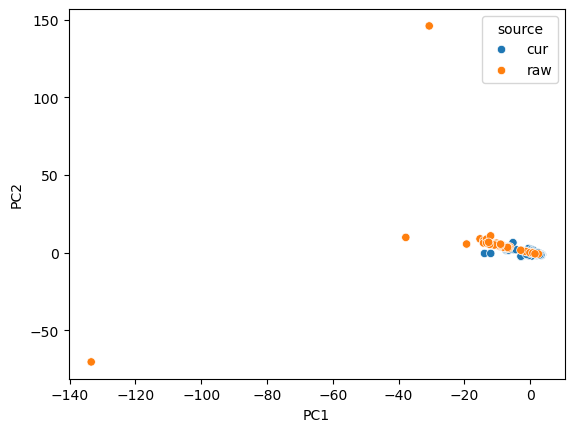

In [188]:
sns.scatterplot(data=pca_plot_df, x='PC1', y='PC2', hue='source')

In originally analyzing the IGLH, there was ALOT of overlap becuase there were minimal edits between the digger and curate annotations. As we can see here with IGLJ however there is not much overlap and we can see that there is a distinction between the two classes that should allow us to create a classifier.

In [347]:
# Dataframe to look at kmer means by class

split_df = filter_final.loc[:, filter_final.columns.str.contains("mer") | (filter_final.columns == 'source')];
split_df = split_df.melt(id_vars=list(split_df.columns[~split_df.columns.str.contains("mer")]));
split_df = split_df.groupby(['variable', 'source']).mean().sort_values(by=['variable', 'source']);
split_df_target = split_df.reset_index().pivot(index='variable', columns='source', values='value');
split_df_target["Difference"] = split_df_target["cur"] - split_df_target["raw"];
split_df_target = split_df_target.sort_values(by="Difference", ascending=False);
print(split_df.head(3));
print(split_df_target.head(3));

                    value
variable source          
2mer_AA  cur     0.018390
         raw     0.035900
2mer_AC  cur     0.002028
source            cur       raw  Difference
variable                                   
2mer_GA      0.049031 -0.483209    0.532240
3mer_GGG     0.031261 -0.385711    0.416971
6mer_CCATGG  0.013103 -0.367881    0.380984


C:\Users\jesse\AppData\Local\Temp\ipykernel_16996\814667542.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha="right");


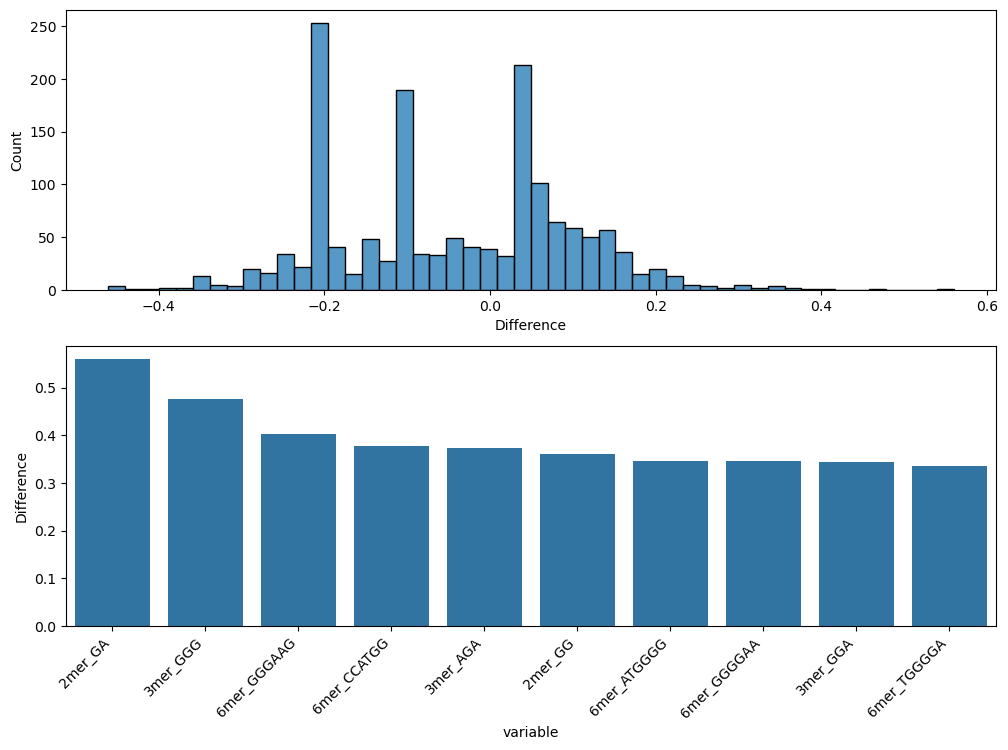

In [293]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8));

sns.histplot(split_df_target["Difference"], bins=50, ax=ax[0]);

sns.barplot(split_df_target.head(10).reset_index(), x = "variable", y="Difference", ax=ax[1]);
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha="right");

Firstly that there is not a huge difference between the two classes overall as we can see from the histogram being fairly close to 0. We can also see from the second graph which sequences seem to be the most different between the two classes which might be a clue as to which features might be important for determining if an annotations is correct or incorrect.

# Classifier
For now I am going to just make a simple decision tree then move into using logistic regression. A decision tree will be interesting for this data becuase it can show what features / kmers can be important for splitting the data. I will then use logistic regression because it will be better at handling the data because of the high number of features it has and I think it will create a stronger model using weights.

In [348]:
# Create X and Y for ML

X_2 = filter_final.loc[:, filter_final.columns.str.contains("2mer")] # Create a training set for 2mers
X_3 = filter_final.loc[:, filter_final.columns.str.contains("3mer")] # Create a training set for 3mers
X_6 = filter_final.loc[:, filter_final.columns.str.contains("6mer")] # Create a training set for 6mers
X_all = filter_final.loc[:, filter_final.columns.str.contains("mer")]

#X = pd.concat([X, filter_final['length']], axis=1) # I decided not to include length for now as I want to focus on if this problem can be solved using Kmers
Y = filter_final['source'].cat.codes

In [212]:
def decision_tree_analysis(X, Y, title):
    clf = DecisionTreeClassifier(random_state=0) # Basic Decision Tree Classifier

    pred_dt = cross_val_predict(clf, X, Y, cv=5) # Initial Test
    print(classification_report(Y, pred_dt)) # Show classification report

    fig, ax = plt.subplots(1, 2, figsize=(10,5))

    cfm = confusion_matrix(Y, pred_dt)
    ConfusionMatrixDisplay(confusion_matrix=cfm).plot(ax=ax[0])
    ax[0].set_title(title)

    clf.fit(X_2, Y)
    ax[1] = tree.plot_tree(
        clf,
        class_names=[str(c) for c in clf.classes_],
        feature_names=[str(f) for f in X.columns],
        filled=True
    );

              precision    recall  f1-score   support

           0       0.77      0.82      0.80       658
           1       0.25      0.20      0.22       200

    accuracy                           0.68       858
   macro avg       0.51      0.51      0.51       858
weighted avg       0.65      0.68      0.66       858



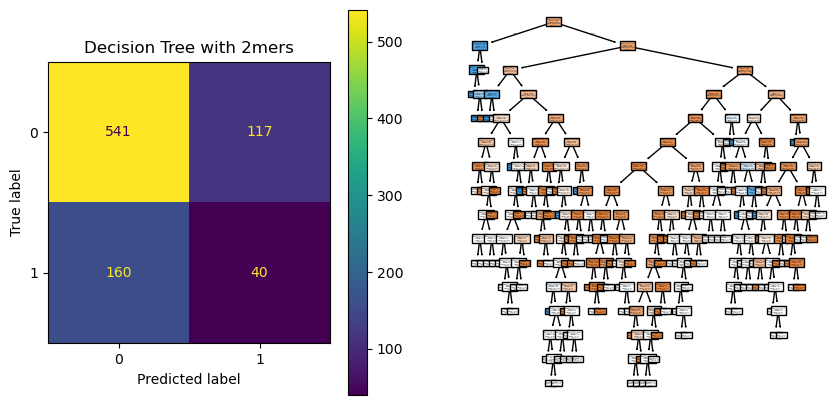

In [349]:
decision_tree_analysis(X_2, Y, "Decision Tree with 2mers")

              precision    recall  f1-score   support

           0       0.78      0.84      0.81       658
           1       0.23      0.17      0.20       184

    accuracy                           0.69       842
   macro avg       0.51      0.50      0.50       842
weighted avg       0.66      0.69      0.68       842



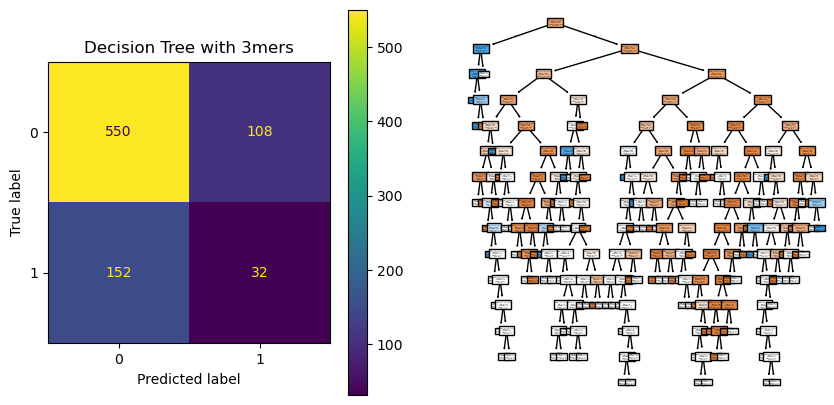

In [296]:
decision_tree_analysis(X_3, Y, "Decision Tree with 3mers")

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       658
           1       0.25      0.21      0.23       184

    accuracy                           0.69       842
   macro avg       0.52      0.52      0.52       842
weighted avg       0.67      0.69      0.68       842



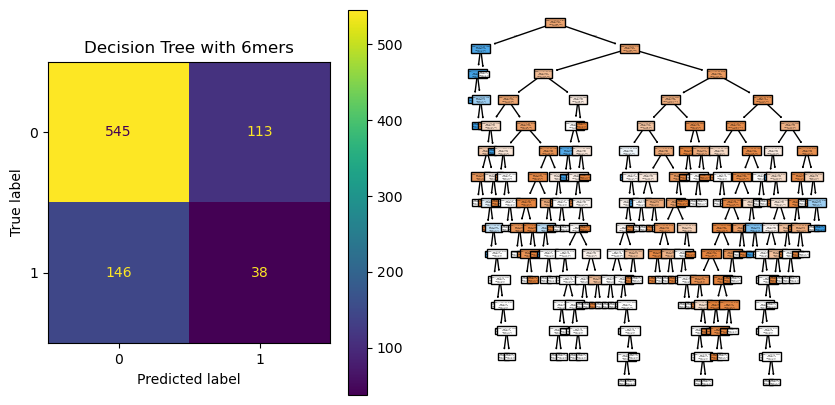

In [297]:
decision_tree_analysis(X_6, Y, "Decision Tree with 6mers")

When I originally conducted this IGLH, I yielded very poor results where my classifier actually performed worse than simple random guessing. Again this is becuase of the huge overlap between the two classes. With IGLJ however we can see that there is a high degree of accuracy because the classes can actually be differentiated. An important part of this tool however is going to be to minimize the False negatives. We only want to remove the annotations that we are certain are inccorect with high confidence. Ideally we want to only check over the annotations we are confident are in the final dataset and minimize how many annotations we must manually look over. Because of this we want to maximize our precision metric.

In [250]:
def grid_search_decision_tree(X, name, Y):
    print(f"Running Grid Search for Decision Tree with {X.columns[0].split('mer')[0]}mers...")
    start_time = time.time()
    param_grid = { 'criterion' : ['gini', 'entropy'],
               'max_depth' : [4,5,6,7,8,9],
               'min_samples_split' : [3,4,5,6],
               'min_samples_leaf' : [1,2,3,4,5]
             }

    grid = GridSearchCV(DecisionTreeClassifier(), param_grid, scoring = ["precision"],
                    refit="precision", n_jobs=-1,
                    return_train_score=True, cv=10)

    grid_result = grid.fit(X,Y)
    end_time = time.time()
    print(f"Best score for decision tree with {name}: {grid_result.best_score_}")
    print(f"Best params for decision tree with {name}: {grid_result.best_params_}")
    print(f"Time taken for decision tree with {name}: {end_time - start_time:.2f} seconds")    

    return grid_result.best_score_, grid_result.best_params_

In [ ]:
def iterate_decision_tree(X_list, names, Y):
    best_df = []
    best_score = 0
    best_params = []
    best_name = ""
    for X, name in zip(X_list, names):
        score, params = grid_search_decision_tree(X, name, Y)
        if score > best_score:
            best_df = X
            best_score = score
            best_params = params
            best_name = name
    print(f"Best overall score: {best_score} with {best_name} and params: {best_params['criterion']}, {best_params['max_depth']}, {best_params['min_samples_split']}, {best_params['min_samples_leaf']}")
    return best_df, best_score, best_params, best_name

In [350]:
dt_best_df, dt_best_score, dt_best_params, dt_best_name = iterate_decision_tree([X_2, X_3, X_6], ["2mer", "3mer", "6mer"], Y)

Running Grid Search for Decision Tree with 2mers...
Best score for decision tree with 2mer: 0.3066666666666667
Best params for decision tree with 2mer: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 3}
Time taken for decision tree with 2mer: 30.91 seconds
Running Grid Search for Decision Tree with 3mers...
Best score for decision tree with 3mer: 0.34368421052631576
Best params for decision tree with 3mer: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 5}
Time taken for decision tree with 3mer: 33.94 seconds
Running Grid Search for Decision Tree with 6mers...
Best score for decision tree with 6mer: 0.1857192626214365
Best params for decision tree with 6mer: {'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 5, 'min_samples_split': 3}
Time taken for decision tree with 6mer: 396.39 seconds
Best overall score: 0.34368421052631576 with 3mer and params: gini, 4, 5, 5


              precision    recall  f1-score   support

           0       0.78      0.95      0.86       658
           1       0.43      0.13      0.20       200

    accuracy                           0.76       858
   macro avg       0.61      0.54      0.53       858
weighted avg       0.70      0.76      0.70       858



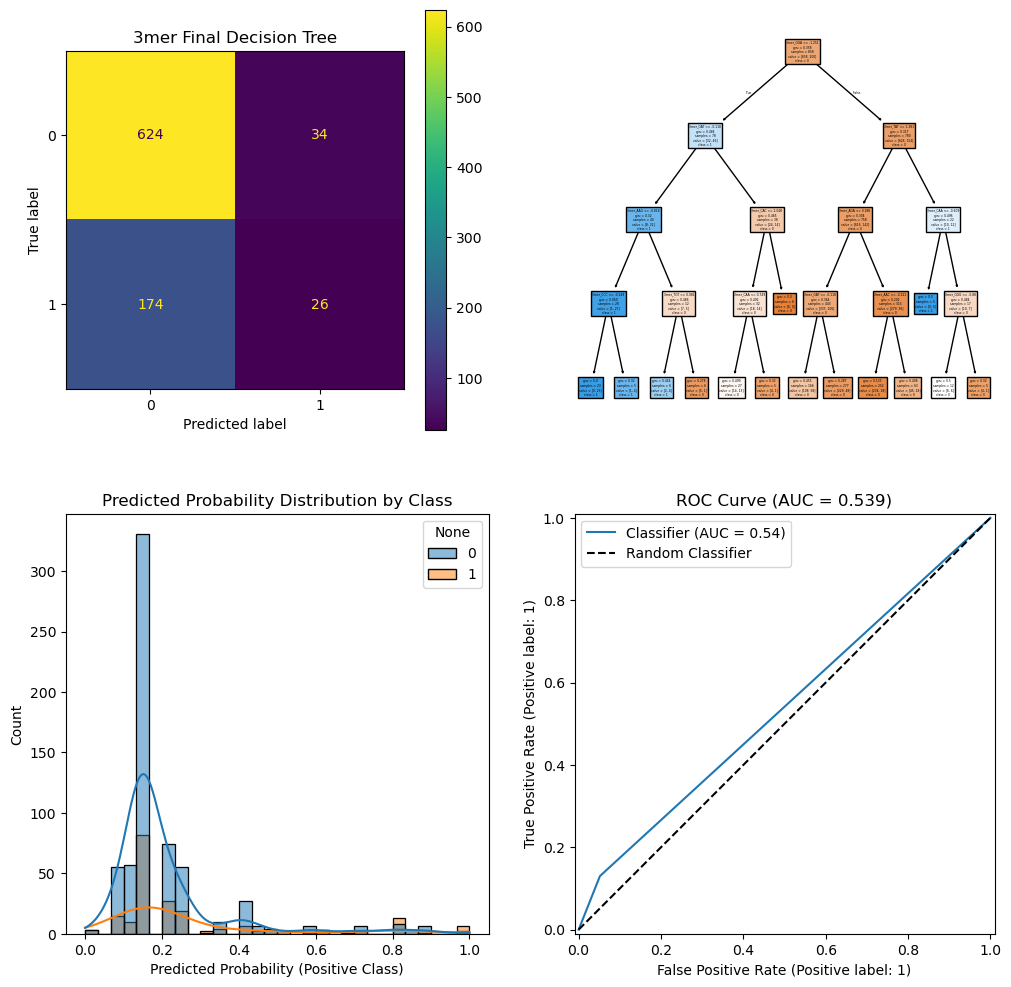

In [351]:
dt_final = DecisionTreeClassifier(criterion=dt_best_params['criterion'], max_depth=dt_best_params['max_depth'], min_samples_split=dt_best_params['min_samples_split'], min_samples_leaf=dt_best_params['min_samples_leaf']) # Decision Tree Classifier based on best params

pred_dt_final = cross_val_predict(dt_final, dt_best_df, Y, cv=5) # Initial Test
print(classification_report(Y, pred_dt_final)) # Show classification report
fig, ax = plt.subplots(2, 2, figsize=(12,12));

cfm = confusion_matrix(Y, pred_dt_final)
ConfusionMatrixDisplay(confusion_matrix=cfm).plot(ax=ax[0, 0])
ax[0, 0].set_title(f"{dt_best_name} Final Decision Tree")

dt_final.fit(dt_best_df, Y)
tree.plot_tree(
    dt_final,
    ax = ax[0, 1],
    class_names=[str(c) for c in dt_final.classes_],
    feature_names=[str(f) for f in dt_best_df.columns],
    filled=True
);

# REVIEW THIS, I DONT FULLY UNDERSTAND IT BUT I THINK IT IS RIGHT
pred_dt_proba = cross_val_predict(dt_final, dt_best_df, Y, cv=5, method='predict_proba')
sns.histplot(x=pred_dt_proba[:, 1], hue=Y, bins=30, ax=ax[1, 0], kde=True)
ax[1, 0].set_title("Predicted Probability Distribution by Class")
ax[1, 0].set_xlabel("Predicted Probability (Positive Class)")

# ROC Curve - CODE YOU CAN USE TO SHOW AN ROC CURVE!
roc_auc = roc_auc_score(Y, pred_dt_final)
RocCurveDisplay.from_predictions(Y, pred_dt_final, ax = ax[1, 1])
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.show()

Although we are looking for the best precision, it seems hard to reduce the 2-3 false negatives using a decision tree. Next we will perform the logistic regression to see how that performs compared to decision trees.

In [218]:
def logistic_regression_analysis(X, Y, title):
    clf_log = LogisticRegression(C=1, random_state=0, max_iter=1000, class_weight='balanced', solver = 'lbfgs')

    pred_log = cross_val_predict(clf_log, X, Y, cv=5) # Initial Test
    print(classification_report(Y, pred_log)) # Show classification report

    fig, ax = plt.subplots(1, 2, figsize=(10,5))

    cfm = confusion_matrix(Y, pred_log)
    ConfusionMatrixDisplay(confusion_matrix=cfm).plot(ax=ax[0])
    ax[0].set_title(title)

    # ROC Curve - CODE YOU CAN USE TO SHOW AN ROC CURVE!
    roc_auc = roc_auc_score(Y, pred_log)
    RocCurveDisplay.from_predictions(Y, pred_log, ax=ax[1])
    ax[1].set_title(f"ROC Curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.legend()
    plt.show()

              precision    recall  f1-score   support

           0       0.99      0.94      0.96       658
           1       0.44      0.76      0.56        38

    accuracy                           0.93       696
   macro avg       0.71      0.85      0.76       696
weighted avg       0.96      0.93      0.94       696



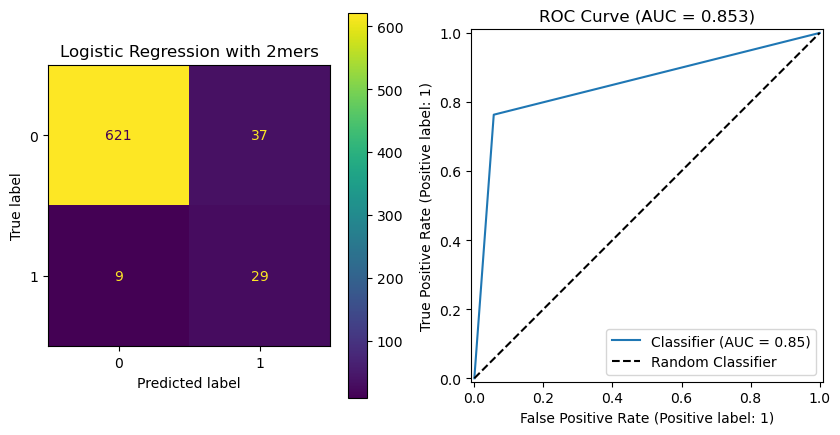

In [219]:
logistic_regression_analysis(X_2, Y, "Logistic Regression with 2mers")

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       658
           1       0.54      0.53      0.53        38

    accuracy                           0.95       696
   macro avg       0.76      0.75      0.75       696
weighted avg       0.95      0.95      0.95       696



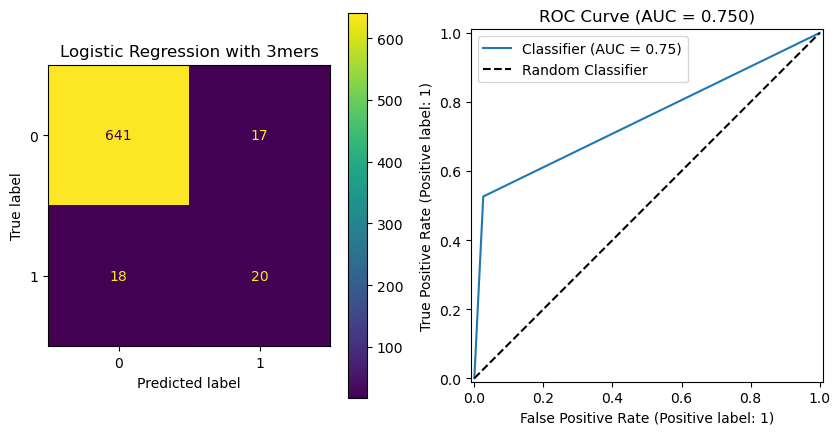

In [220]:
logistic_regression_analysis(X_3, Y, "Logistic Regression with 3mers")

Off the bat it seems to better. Whats also interesting is that as we increased the size of the kmers, the AUC value increased. Lets use grid search again in order to see if we can maximize the precision metric. I will say while playing with this I on accident chose the trimer data and saw I got good results which is why I opted to use this data.

In [ ]:
def grid_search_logistic_regression(X, name, Y):
    print(f"Running Grid Search for Logistic Regression with {X.columns[0].split('mer')[0]}mers...")
    start_time = time.time()
    param_grid = { 'C' : [0.1, 1, 10, 100, 1000],
            'class_weight' : ['balanced', None],
            'solver' : ['lbfgs', 'liblinear', 'sag', 'saga', 'newton-cg']
            }

    grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, scoring = ["precision"],
                        refit="precision", n_jobs=-1,
                        return_train_score=True, cv=10)

    grid_result = grid.fit(X,Y)
    end_time = time.time()
    print(f"Best score for logistic regression with {name}: {grid_result.best_score_}")
    print(f"Best params for logistic regression with {name}: {grid_result.best_params_}")
    print(f"Time taken for logistic regression with {name}: {end_time - start_time:.2f} seconds")    

    return grid_result.best_score_, grid_result.best_params_

In [274]:
def iterate_logistic_regression(X_list, names, Y):
    best_df = None
    best_score = 0
    best_params = []
    best_name = ""
    for X, name in zip(X_list, names):
        score, params = grid_search_logistic_regression(X, name, Y)
        if score > best_score:
            best_df = X
            best_score = score
            best_params = params
            best_name = name
    print(f"Best overall score: {best_score} with {best_name} and params: {best_params["C"]}, {best_params["class_weight"]}, {best_params["solver"]}")
    return best_df, best_score, best_params, best_name

In [300]:
log_df, log_score, log_params, log_name = iterate_logistic_regression([X_2, X_3, X_6], ['2-mer', '3-mer', '6-mer'], Y)

Running Grid Search for Logistic Regression with 2mers...
Best score for logistic regression with 2-mer: 0.5244444444444445
Best params for logistic regression with 2-mer: {'C': 0.1, 'class_weight': None, 'solver': 'liblinear'}
Time taken for logistic regression with 2-mer: 13.40 seconds
Running Grid Search for Logistic Regression with 3mers...
Best score for logistic regression with 3-mer: 0.4241687192118226
Best params for logistic regression with 3-mer: {'C': 10, 'class_weight': None, 'solver': 'liblinear'}
Time taken for logistic regression with 3-mer: 16.27 seconds
Running Grid Search for Logistic Regression with 6mers...
Best score for logistic regression with 6-mer: 0.45285333631885355
Best params for logistic regression with 6-mer: {'C': 1, 'class_weight': 'balanced', 'solver': 'lbfgs'}
Time taken for logistic regression with 6-mer: 318.08 seconds
Best overall score: 0.5244444444444445 with 2-mer and params: 0.1, None, liblinear


c:\Users\jesse\anaconda3\envs\ImmunoglobulinML\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.80      0.98      0.88       658
           1       0.64      0.12      0.21       184

    accuracy                           0.79       842
   macro avg       0.72      0.55      0.55       842
weighted avg       0.76      0.79      0.73       842



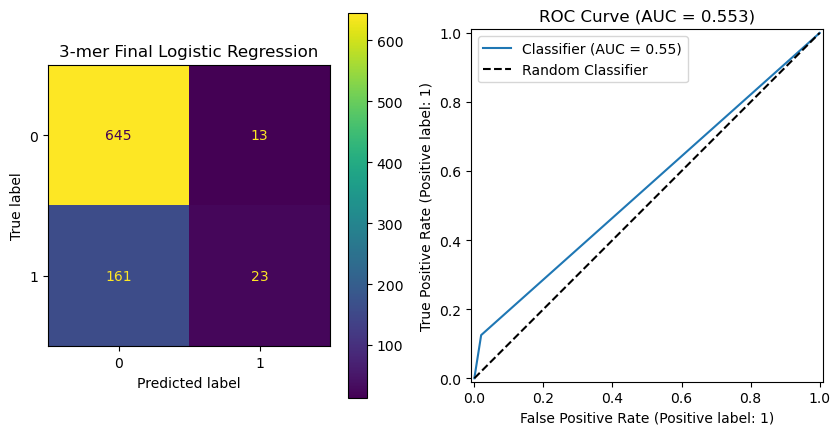

In [301]:
clf_log_final = LogisticRegression(C = log_params['C'], max_iter = 1000, class_weight = log_params['class_weight'], solver = log_params['solver'])

pred_log_final = cross_val_predict(clf_log_final, log_df, Y, cv=10) # Initial Test
print(classification_report(Y, pred_log_final)) # Show classification report

fig, ax = plt.subplots(1, 2, figsize=(10,5))

cfm = confusion_matrix(Y, pred_log_final)
ConfusionMatrixDisplay(confusion_matrix=cfm).plot(ax=ax[0])
ax[0].set_title("3-mer Final Logistic Regression")

# ROC Curve - CODE YOU CAN USE TO SHOW AN ROC CURVE!
roc_auc = roc_auc_score(Y, pred_log_final)
RocCurveDisplay.from_predictions(Y, pred_log_final, ax=ax[1])
ax[1].set_title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.show()
plt.show()

We were able to get 100% precision using logistic regression! Lets take a look at the results that were incorrectly identified before finishing up.

In [282]:
dt_false_results = pd.concat([pca_plot_df, pd.Series(pred_dt_final, name='Guess')], axis=1)
dt_false_results["Correct"] = np.where(dt_false_results['source'].cat.codes == dt_false_results['Guess'], 'Correct', 'Incorrect')
dt_false_results["Correct"] = dt_false_results["Correct"].astype('category')
dt_false_results.head(3)

,PC1,PC2,PC3,source,Guess,Correct
0,-0.092450,0.775023,-0.400896,cur,0,Correct
1,-7.345647,1.454438,-5.265933,cur,0,Correct
2,0.558326,-0.116753,0.638596,cur,0,Correct


In [283]:
log_false_results = pd.concat([pca_plot_df, pd.Series(pred_log_final, name='Guess')], axis=1)
log_false_results["Correct"] = np.where(log_false_results['source'].cat.codes == log_false_results['Guess'], 'Correct', 'Incorrect')
log_false_results["Correct"] = log_false_results["Correct"].astype('category')
log_false_results.head(3)

,PC1,PC2,PC3,source,Guess,Correct
0,-0.092450,0.775023,-0.400896,cur,0,Correct
1,-7.345647,1.454438,-5.265933,cur,1,Incorrect
2,0.558326,-0.116753,0.638596,cur,0,Correct


Text(0.5, 1.0, 'Logistic Regression')

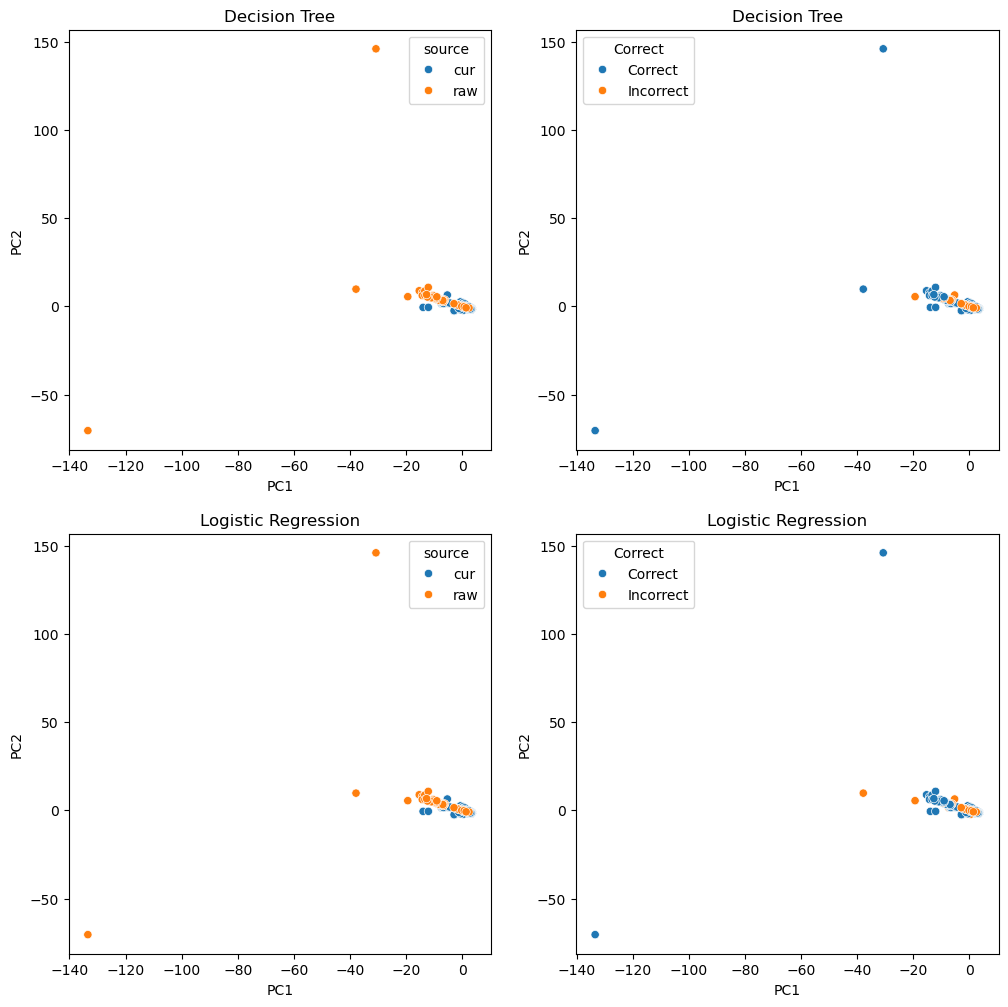

In [287]:
fig, ax = plt.subplots(2, 2, figsize=(12, 12));

sns.scatterplot(data=dt_false_results, x='PC1', y='PC2', hue='source', ax = ax[0, 0]);
ax[0, 0].set_title("Decision Tree")
sns.scatterplot(data=dt_false_results, x='PC1', y='PC2', hue='Correct', ax = ax[0, 1]);
ax[0, 1].set_title("Decision Tree")
sns.scatterplot(data=log_false_results, x='PC1', y='PC2', hue='source', ax = ax[1, 0]);
ax[1, 0].set_title("Logistic Regression")
sns.scatterplot(data=log_false_results, x='PC1', y='PC2', hue='Correct', ax = ax[1, 1]);
ax[1, 1].set_title("Logistic Regression")

Text(0.5, 0, 'PC3')

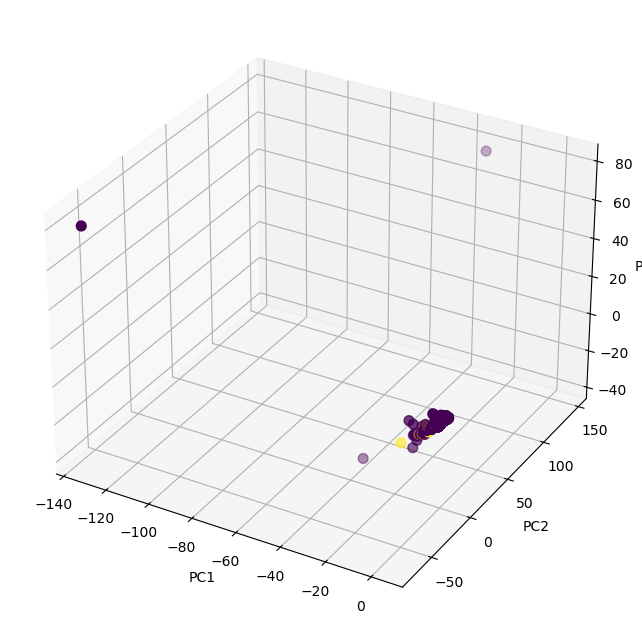

In [289]:
fig = plt.figure(figsize = (8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(dt_false_results.iloc[:,0], dt_false_results.iloc[:,1], dt_false_results.iloc[:,2], c=dt_false_results['Correct'].cat.codes, cmap='viridis', s=50)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

Text(0.5, 0, 'PC3')

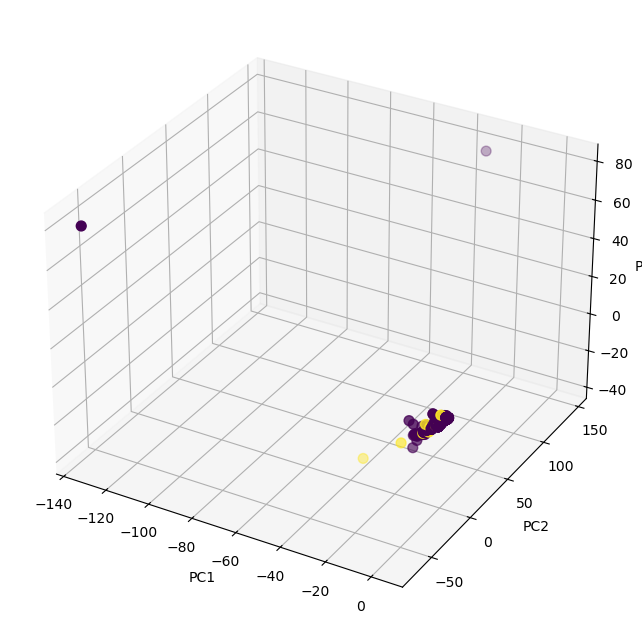

In [288]:
fig = plt.figure(figsize = (8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(log_false_results.iloc[:,0], log_false_results.iloc[:,1], log_false_results.iloc[:,2], c=log_false_results['Correct'].cat.codes, cmap='viridis', s=50)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

I am unsure as to why the data points that were incorrectly identified were incorrectly identified because they are not on what I would imagine to be the border between the two classes.

# Conclusion

Ultimately this project was succesful in being able to differentiate raw digger output from polished curated annotations. We also were able to minimize the number of false negatives to 0 which would prevent the need for a user to review the annotations identified as incorrect. I think using a larger dataset would benefit this study in order to truly see how accurate it could be and to also see if it could have real world use.

# Acknowledgements

I would like to thank Dr Ken Field, Ashley Reers for guidance on the biological side of working on this project in addition to providing me with the data for this project. I would also like to thank Dr Brian King for his help on the technical side of this project.

ChatGPT and Copilot was used on this project for both coding and help understanding differences however everything written in a markdown is my own writing.